# Prototipo — Detección de lesión periapical y diente impactado en radiografías panorámicas
**Comparación YOLO11n vs. YOLO26n** · Conjunto de datos: DENTEX (https://doi.org/10.5281/zenodo.7812323)

## 1. Información del sistema y objetivo
Este cuaderno es el prototipo funcional del sistema. Permite:
1. cargar una radiografía panorámica (o elegir una de la partición de **prueba**);
2. seleccionar el modelo entrenado (YOLO11n o YOLO26n);
3. procesar la imagen automáticamente;
4. ver las detecciones (caja, clase y confianza) sobre la radiografía;
5. obtener un resumen interpretable y, opcionalmente, comparar ambos modelos.

**Clases detectadas:** `lesión periapical` (rojo) y `diente impactado` (verde).

**Cómo usarlo:** ejecuta las celdas en orden (Entorno de ejecución → Ejecutar todo). En las celdas con formulario (secciones 4 y 6) cambia las opciones y vuelve a ejecutarlas.

> ⚠️ **Aviso:** es un prototipo de investigación. Las detecciones indican concordancia algorítmica con las anotaciones del conjunto DENTEX y **no constituyen un diagnóstico clínico**. Requiere GPU (Entorno de ejecución → Cambiar tipo → GPU) para tiempos similares a los del artículo (Tesla T4).

## 2. Instalación de dependencias

In [1]:
%pip install -q "ultralytics==8.4.118"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.6 MB/s eta 0:00:00


## 3. Carga de los modelos entrenados
Los pesos (`best.pt`) se leen de Google Drive. Si no existen en la ruta indicada, el cuaderno te pedirá subirlos. Los umbrales de confianza por defecto (0,46 y 0,17) son los elegidos en la partición de **validación** (ver artículo).

In [2]:
import json, zipfile, time, random
from pathlib import Path
import numpy as np, pandas as pd, cv2, torch
import matplotlib.pyplot as plt
import ultralytics
from ultralytics import YOLO
from google.colab import drive, files
drive.mount('/content/drive')

if ultralytics.__version__ != "8.4.118":
    print("AVISO: los modelos se entrenaron con ultralytics 8.4.118; versión actual:", ultralytics.__version__)

# ---- Rutas (ajústalas si cambiaste la estructura de Drive) ----
ROOT        = Path("/content/drive/MyDrive/UNIVERSIDAD/10MO SEMESTRE/ARTICULO II")
DATASET_ZIP = ROOT / "DATASET" / "DENTEX-YOLO-2clases.zip"     # solo se usa para elegir imágenes de prueba
WEIGHTS = {
    "YOLO11n": ROOT / "MODELOS" / "YOLO11" / "yolo11n_seed42" / "weights" / "best.pt",
    "YOLO26n": ROOT / "MODELOS" / "YOLO26" / "yolo26n_seed42" / "weights" / "best.pt",
}
THRESH_VAL = {"YOLO11n": 0.46, "YOLO26n": 0.17}   # umbral que maximiza F1 en validación
IMGSZ = 1024
CLASS_ES  = ["lesión periapical", "diente impactado"]
CLASS_COL = [(1.0, 0.25, 0.25), (0.15, 0.8, 0.15)]
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (será más lento)")

MODELS = {}
for name, path in WEIGHTS.items():
    if not path.exists():
        print(f"No se encontró {path}\nSube el archivo best.pt de {name}:")
        up = files.upload()
        path = Path("/content") / next(iter(up))
    MODELS[name] = YOLO(str(path))
    MODELS[name].predict(np.zeros((640, 1280, 3), np.uint8), imgsz=IMGSZ, verbose=False, device=DEVICE)  # calentamiento
print("Modelos cargados:", list(MODELS))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Dispositivo: Tesla T4
Modelos cargados: ['YOLO11n', 'YOLO26n']


## 4. Carga de una radiografía por parte del usuario
- `SOURCE = "subir"`: aparece un botón para **cargar tu propia radiografía** (PNG/JPG).
- `SOURCE = "test"`: usa una imagen de la partición de **prueba** de DENTEX (imágenes que el modelo nunca vio ni para entrenar ni para elegir el umbral). Deja `TEST_IMAGE` vacío para una al azar, o escribe un nombre (p. ej. `train_123.png`). En este modo se dibuja también la anotación de referencia (amarillo discontinuo).

In [16]:
#@title Selección de la imagen { run: "auto" }
SOURCE = "subir" #@param ["subir", "test"]
TEST_IMAGE = "" #@param {type:"string"}

def decode(b):
    return cv2.imdecode(np.frombuffer(b, np.uint8), cv2.IMREAD_COLOR)   # BGR

GT, IMG_NAME = None, None
if SOURCE == "subir":
    up = files.upload()
    assert up, "No se subió ningún archivo."
    IMG_NAME = next(iter(up)); IMG = decode(up[IMG_NAME])
else:
    with zipfile.ZipFile(DATASET_ZIP) as zf:
        test_names = sorted(zf.read("splits/test.txt").decode().split())
        random.seed(42)
        IMG_NAME = TEST_IMAGE.strip() or random.choice(test_names)
        assert IMG_NAME in test_names, "Esa imagen no pertenece a la partición de prueba."
        IMG = decode(zf.read(f"images/test/{IMG_NAME}"))
        H, W = IMG.shape[:2]
        rows = [l.split() for l in zf.read(f"labels/test/{Path(IMG_NAME).stem}.txt").decode().splitlines() if l.strip()]
        GT = [{"cls": int(c), "box": ((float(x)-float(w)/2)*W, (float(y)-float(h)/2)*H,
                                      (float(x)+float(w)/2)*W, (float(y)+float(h)/2)*H)} for c, x, y, w, h in rows]
assert IMG is not None, "No se pudo leer la imagen. Usa PNG o JPG."
print("Imagen:", IMG_NAME, "| fuente:", SOURCE)

Saving imagen_2026-10-08_023748159.png to imagen_2026-10-08_023748159.png
Imagen: imagen_2026-10-08_023748159.png | fuente: subir


## 5. Preprocesamiento
La imagen se convierte a RGB y se valida. El **redimensionado con relleno (letterbox) a 1024 × 1024 px** y la normalización los hace automáticamente Ultralytics al inferir, igual que durante el entrenamiento; las cajas se devuelven en las coordenadas de la imagen original.

Tamaño original: 800 × 413 px | proporción ancho/alto: 1.94


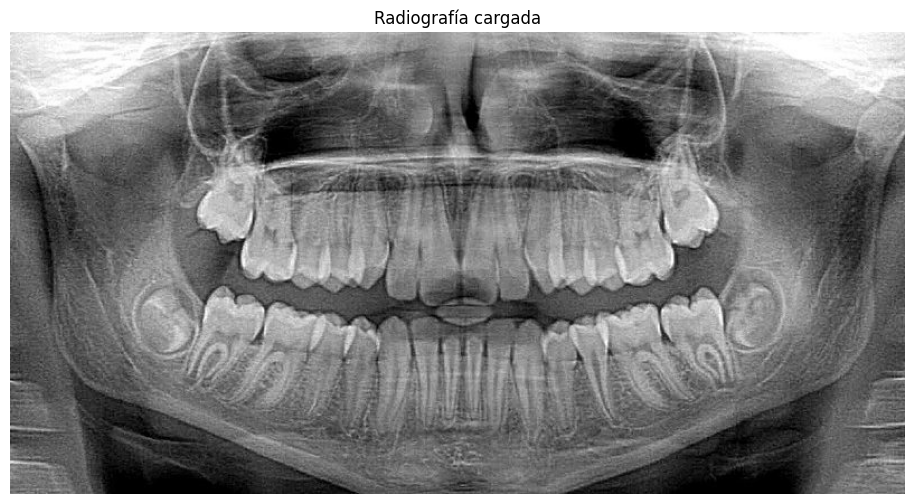

In [17]:
H, W = IMG.shape[:2]
IMG_RGB = cv2.cvtColor(IMG, cv2.COLOR_BGR2RGB)
print(f"Tamaño original: {W} × {H} px | proporción ancho/alto: {W/H:.2f}")
if W / H < 1.5:
    print("AVISO: la proporción no parece la de una radiografía panorámica (típicamente ≈ 2:1). "
          "El modelo se entrenó solo con panorámicas; los resultados pueden no ser fiables.")
plt.figure(figsize=(12, 6)); plt.imshow(IMG_RGB); plt.axis("off"); plt.title("Radiografía cargada"); plt.show()

## 6. Inferencia con el modelo seleccionado
Elige el modelo y el umbral de confianza. Por defecto se usa el umbral elegido en validación para cada modelo; con `personalizado` puedes bajarlo (más detecciones, más falsos positivos) o subirlo.

In [18]:
#@title Modelo y umbral { run: "auto" }
MODEL_CHOICE = "YOLO26n" #@param ["YOLO11n", "YOLO26n"]
CONF_MODE = "umbral de validación" #@param ["umbral de validación", "personalizado"]
CONF_CUSTOM = 0.25 #@param {type:"slider", min:0.05, max:0.95, step:0.01}

def run_model(name, img_bgr, conf):
    r = MODELS[name].predict(img_bgr, imgsz=IMGSZ, conf=conf, iou=0.7, max_det=100, verbose=False, device=DEVICE)[0]
    dets = [{"cls": int(c), "conf": float(p), "box": tuple(map(float, b))}
            for b, c, p in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.cls.cpu().numpy(), r.boxes.conf.cpu().numpy())]
    dets.sort(key=lambda d: -d["conf"])
    s = r.speed
    return dets, {"preproceso_ms": s["preprocess"], "inferencia_ms": s["inference"],
                  "posproceso_ms": s["postprocess"], "total_ms": s["preprocess"] + s["inference"] + s["postprocess"]}

CONF = THRESH_VAL[MODEL_CHOICE] if CONF_MODE == "umbral de validación" else CONF_CUSTOM
DETS, TIMES = run_model(MODEL_CHOICE, IMG, CONF)
print(f"Modelo: {MODEL_CHOICE} | umbral de confianza: {CONF:.2f} | detecciones: {len(DETS)} | tiempo total: {TIMES['total_ms']:.1f} ms")

Modelo: YOLO26n | umbral de confianza: 0.17 | detecciones: 6 | tiempo total: 41.0 ms


## 7. Visualización de resultados

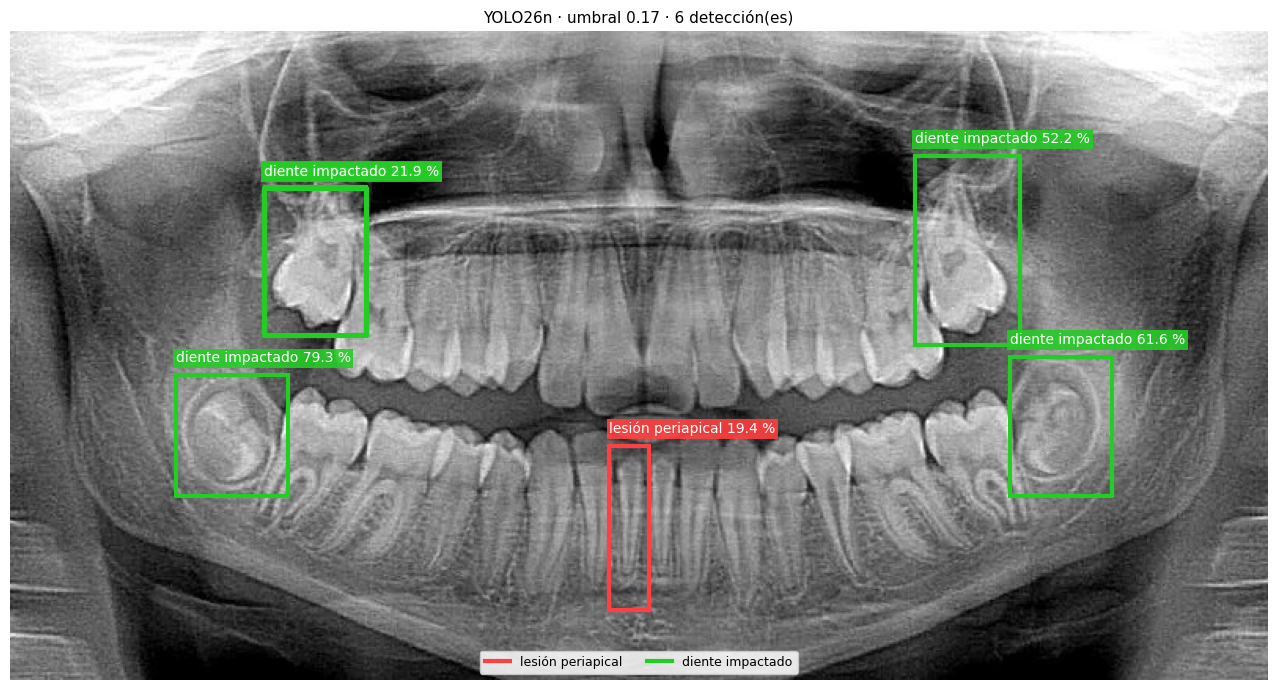

Imagen guardada en: /content/resultados_prototipo/imagen_2026-10-08_023748159_YOLO26n.png


In [19]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def draw(ax, img_rgb, dets, title, gt=None):
    ax.imshow(img_rgb)
    if gt:
        for g in gt:
            x1, y1, x2, y2 = g["box"]
            ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="yellow", lw=2, ls="--"))
    for d in dets:
        x1, y1, x2, y2 = d["box"]; c = CLASS_COL[d["cls"]]
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec=c, lw=3))
        ax.text(x1, max(y1-8, 20), f"{CLASS_ES[d['cls']]} {d['conf']*100:.1f} %", color="white", fontsize=10,
                bbox=dict(facecolor=c, alpha=.9, pad=2, lw=0))
    ax.set_title(title, fontsize=11); ax.axis("off")

def legend(ax, with_gt):
    h = [Line2D([0], [0], color=CLASS_COL[i], lw=3, label=CLASS_ES[i]) for i in (0, 1)]
    if with_gt: h.append(Line2D([0], [0], color="yellow", lw=2, ls="--", label="anotación de referencia"))
    ax.legend(handles=h, loc="lower center", ncol=3, fontsize=9, framealpha=.85)

fig, ax = plt.subplots(figsize=(14, 7))
draw(ax, IMG_RGB, DETS, f"{MODEL_CHOICE} · umbral {CONF:.2f} · {len(DETS)} detección(es)", gt=GT)
legend(ax, GT is not None)
plt.tight_layout()
OUT = Path("/content/resultados_prototipo"); OUT.mkdir(exist_ok=True)
out_png = OUT / f"{Path(IMG_NAME).stem}_{MODEL_CHOICE}.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight"); plt.show()
print("Imagen guardada en:", out_png)

## 8. Resumen de detecciones encontradas

In [20]:
if not DETS:
    print("No se detectaron lesiones periapicales ni dientes impactados con este umbral.")
else:
    for i, d in enumerate(DETS, 1):
        print(f"Detección {i}")
        print(f"  Patología detectada: {CLASS_ES[d['cls']]}")
        print(f"  Confianza: {d['conf']*100:.1f} %")
        print(f"  Modelo: {MODEL_CHOICE}\n")
    tabla = pd.DataFrame([{"n": i, "patología": CLASS_ES[d["cls"]], "confianza_%": round(d["conf"]*100, 1),
                           "x1": round(d["box"][0]), "y1": round(d["box"][1]),
                           "x2": round(d["box"][2]), "y2": round(d["box"][3])} for i, d in enumerate(DETS, 1)])
    display(tabla)
    print("Resumen por clase:", {CLASS_ES[c]: sum(d["cls"] == c for d in DETS) for c in (0, 1)})
    tabla.to_csv(OUT / f"{Path(IMG_NAME).stem}_{MODEL_CHOICE}_detecciones.csv", index=False)
print("\nTiempos (ms):", {k: round(v, 1) for k, v in TIMES.items()})

Detección 1
  Patología detectada: diente impactado
  Confianza: 79.3 %
  Modelo: YOLO26n

Detección 2
  Patología detectada: diente impactado
  Confianza: 61.6 %
  Modelo: YOLO26n

Detección 3
  Patología detectada: diente impactado
  Confianza: 52.2 %
  Modelo: YOLO26n

Detección 4
  Patología detectada: diente impactado
  Confianza: 45.1 %
  Modelo: YOLO26n

Detección 5
  Patología detectada: diente impactado
  Confianza: 21.9 %
  Modelo: YOLO26n

Detección 6
  Patología detectada: lesión periapical
  Confianza: 19.4 %
  Modelo: YOLO26n



,n,patología,confianza_%,x1,y1,x2,y2
0,1,diente impactado,79.3,105,218,176,295
1,2,diente impactado,61.6,636,207,700,296
2,3,diente impactado,52.2,575,79,642,199
3,4,diente impactado,45.1,162,99,226,194
4,5,diente impactado,21.9,161,100,226,193
5,6,lesión periapical,19.4,381,264,406,368


Resumen por clase: {'lesión periapical': 1, 'diente impactado': 5}

Tiempos (ms): {'preproceso_ms': 5.9, 'inferencia_ms': 12.8, 'posproceso_ms': 22.3, 'total_ms': 41.0}


## 9. Comparación opcional entre YOLO11n y YOLO26n
Ejecuta ambos modelos sobre la misma imagen, cada uno con su umbral de validación. La primera medición puede ser algo más lenta; para tiempos comparables ejecuta la celda dos veces.

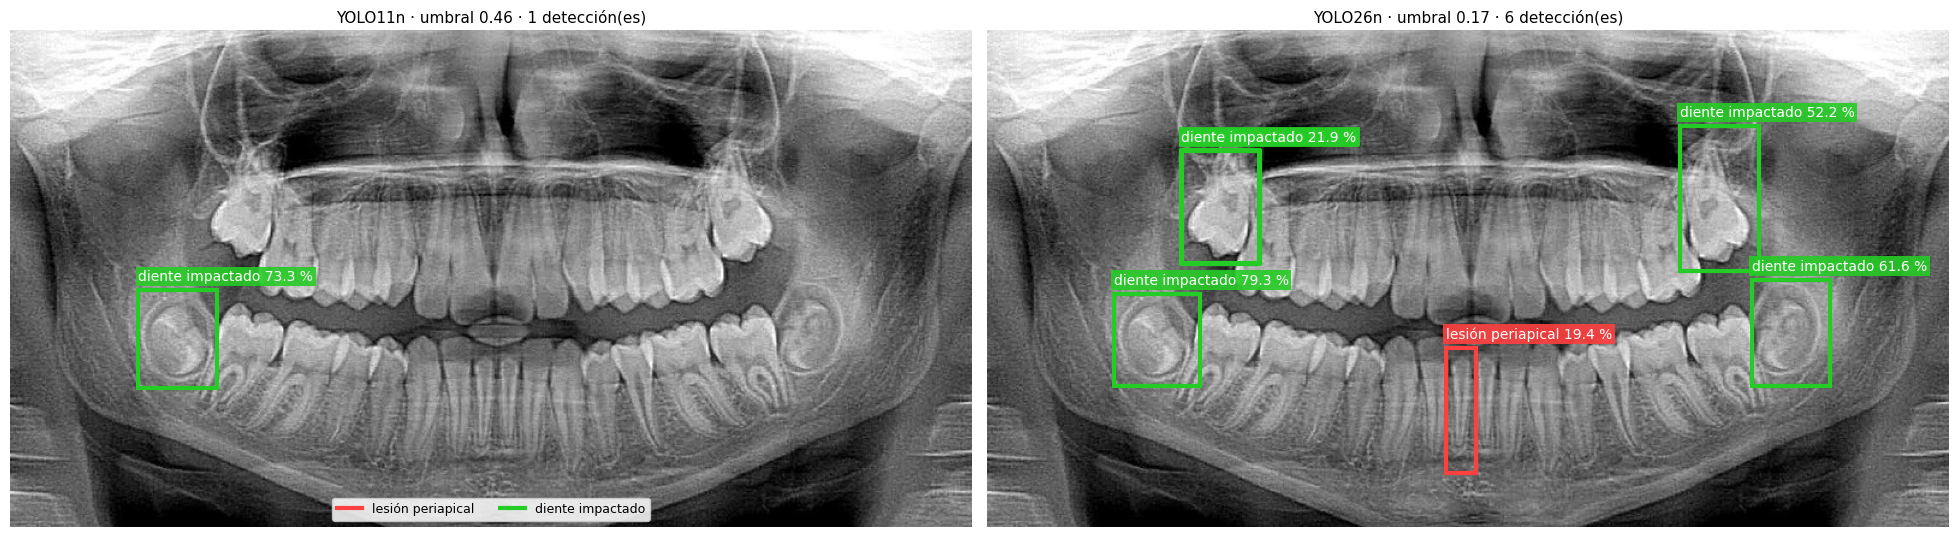

,modelo,umbral,detecciones,lesión periapical,diente impactado,conf. máx. %,tiempo total (ms)
0,YOLO11n,0.46,1,0,1,73.3,20.1
1,YOLO26n,0.17,6,1,5,79.3,17.0


In [21]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6)); rows = []
for ax, name in zip(axs, ["YOLO11n", "YOLO26n"]):
    dets, t = run_model(name, IMG, THRESH_VAL[name])
    draw(ax, IMG_RGB, dets, f"{name} · umbral {THRESH_VAL[name]:.2f} · {len(dets)} detección(es)", gt=GT)
    rows.append({"modelo": name, "umbral": THRESH_VAL[name], "detecciones": len(dets),
                 "lesión periapical": sum(d["cls"] == 0 for d in dets), "diente impactado": sum(d["cls"] == 1 for d in dets),
                 "conf. máx. %": round(max([d["conf"] for d in dets], default=0) * 100, 1),
                 "tiempo total (ms)": round(t["total_ms"], 1)})
legend(axs[0], GT is not None); plt.tight_layout()
fig.savefig(OUT / f"{Path(IMG_NAME).stem}_comparacion.png", dpi=130, bbox_inches="tight"); plt.show()
display(pd.DataFrame(rows))

### Descargar resultados

In [9]:
import shutil
shutil.make_archive("/content/resultados_prototipo", "zip", OUT)
files.download("/content/resultados_prototipo.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
**Referencias del sistema:** conjunto de datos DENTEX (Hamamci et al., 2023; Zenodo, https://doi.org/10.5281/zenodo.7812323). Modelos: Ultralytics YOLO11n y YOLO26n, entrenados con el protocolo descrito en el artículo (1024 px, semilla 42).